# Example of how to use topological data analysis features

Using QM7.

This includes examples of regression models.

In [22]:
import sys

import deepchem as dc

import tensorflow as tf
import os
import sys
import rdkit
import h5py
import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri
import rdkit.Chem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

# topology stuff
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

from pathlib import Path

_base_dir = Path.cwd().parent
_src_dir = str(_base_dir / "src")
if _src_dir not in sys.path:
    sys.path.append(_src_dir)



base_dir = Path.cwd().resolve().parent 
results_dir = base_dir / "output" / "results" / "qm7"
data_dir = base_dir / "datasets" / "after_processing" / "qm7" 



import helper_functions as h
#from projection.face import Face


test_file='qm7.csv'
data_file_name='qm7_topological_features.hdf5'
make_dataset=False # whether to recalc the dataset


print(f"DeepChem version: {dc.__version__}")
print(f"data_dir is {data_dir}")

############################### settings for all experiments #################

num_repeats=10
num_epochs = 500

metric_labels=['mean_squared_error','pearson_r2_score',
               'mae_score', 'rmse']


metric1 = dc.metrics.Metric(dc.metrics.mean_squared_error)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metric3 = dc.metrics.Metric(dc.metrics.mae_score)
metrics = [metric1, metric2, metric3]
selected_metric = 2 #which metric to use for callback

TensorFlow version: 2.19.0
DeepChem version: 2.8.0
data_dir is C:\Users\ella_\Documents\GitHub\GandT\datasets\after_processing\qm7


#### This loads in the topological features (for qm7)
And gives you some information about the file. Note that the molecule counting is broken!

`fh` is the file handle for the topological features file, we use this to read data from the file.

In [23]:
hdf5_file_name='qm7_topological_features.hdf5'
fh = h5py.File(os.path.join(data_dir,hdf5_file_name), 'r+')
num_of_rows, num_of_molecules = h.basic_info_hdf5_dataset(fh, label='molID')

num_of_ rows is:	6838
num_of_molecules is:	 128
MolID: count
Counter({127: 6711, 0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1})


This gives you the keys to the database. The topological features are the ones in the `feature_name_list` (see below). The `PCA_x` are another set of features you could use (they result from a principal component analysis of the topological features). 

In [24]:
fh.keys()

<KeysViewHDF5 ['PCA_1', 'PCA_10', 'PCA_11', 'PCA_12', 'PCA_13', 'PCA_14', 'PCA_15', 'PCA_16', 'PCA_17', 'PCA_18', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'SMILES', 'bottle_1', 'bottle_2', 'bottle_3', 'landsc_1', 'landsc_2', 'landsc_3', 'molID', 'no_p_1', 'no_p_2', 'no_p_3', 'pers_S_1', 'pers_S_2', 'pers_S_3', 'pers_img_1', 'pers_img_2', 'pers_img_3', 'u0_atom', 'u0_atom_norm', 'wasser_1', 'wasser_2', 'wasser_3']>

For this dataset, the target is `u0_atom` which is also in the dataset.

In [25]:
fh['u0_atom'][:]

array([ -417.96,  -712.42,  -564.21, ..., -1523.  , -1778.6 , -1531.9 ],
      dtype=float32)

In [26]:
# list of topological features, this is what we learn from
feature_name_list = ['pers_S_1', 'pers_S_2', 'pers_S_3',
                    'no_p_1', 'no_p_2', 'no_p_3',
                    'bottle_1', 'bottle_2', 'bottle_3',
                    'wasser_1', 'wasser_2', 'wasser_3',
                    'landsc_1', 'landsc_2', 'landsc_3',
                    'pers_img_1', 'pers_img_2', 'pers_img_3']

# alternative features
PCA_list = ['PCA_1', 'PCA_2', 'PCA_3',
           'PCA_4', 'PCA_5', 'PCA_6',
           'PCA_7', 'PCA_8', 'PCA_9',
           'PCA_10', 'PCA_11', 'PCA_12',
           'PCA_13', 'PCA_14', 'PCA_15',
           'PCA_16', 'PCA_17', 'PCA_18']

# tasks to do
tasks = ['u0_atom']

This code sets up our `X` and `y` data, creates the proper transformers  (normalisation for this dataset, use balancing transformers for the classification datasets). 

In [27]:
## loading data from the hdf5 file
# takes data from the hdf5 file and puts it into a variable called X_data
X_data = h.load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=feature_name_list)

PCA_X_data = h.load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=PCA_list)

y_data = h.load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=tasks)

# makes a list of SMILES strings
SMILES_list = np.array(fh['SMILES'])

# this makes the actual topological datasets
topol_dataset = dc.data.DiskDataset.from_numpy(
    X_data, 
    y_data, 
    ids=SMILES_list)

pca_dataset = dc.data.DiskDataset.from_numpy(
    PCA_X_data, 
    y_data, 
    ids=SMILES_list)

# setting up the splitters for the task
Splitter_Object = dc.splits.SingletaskStratifiedSplitter()


# doing a transform on the data to make it easier for hte NN
# normalises both y and x
## for use with topol_dataset
transformers_tf = [
    dc.trans.NormalizationTransformer(
        transform_X=True, 
        dataset=topol_dataset),
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=topol_dataset)]
# normalises only y (as doing a PCA is a type of normalisation)
# for use with pca_dataset
transformers_pca = [
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=pca_dataset)]



## Plot of $y$ data (target)

Text(0, 0.5, 'No.')

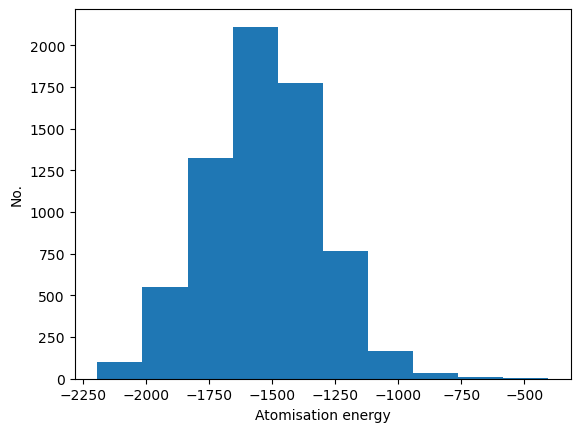

In [28]:
plt.hist(y_data)
plt.xlabel('Atomisation energy')
plt.ylabel("No.")

## Training

 first we shuffle and split our dataset

In [29]:
# This is the splitter we're using, look at the DeepChem 
# paper to see which one you should use
Splitter_Object = dc.splits.SingletaskStratifiedSplitter()
# This shuffles the data and makes 
# the train, test and validate datasets from
# the topologcal data
train_dataset, valid_dataset, test_dataset = Splitter_Object.train_valid_test_split(
    dataset=topol_dataset,
    frac_train=0.8,
    frac_valid=0.1,
    frac_test=0.1)
# this builds the datasets for training

print(f"Training with {len(train_dataset.y)} points")
print(f"Validation with {len(valid_dataset.y)} points")
print(f"Testing with {len(test_dataset.y)} points")
print(f"Total dataset size: {len(train_dataset.y) + len(valid_dataset.y) + len(test_dataset.y)}")


Training with 5464 points
Validation with 683 points
Testing with 683 points
Total dataset size: 6830


Now we must do the transform on our data. If we were using the standard deepchem datasets it is set up to pick the correct transformer and do it for us. With the topological data, we have to to the transforms ourselves.

In [30]:
# transforms datasets wooo
train_dataset = h.do_transform(transformers_tf, train_dataset)
valid_dataset = h.do_transform(transformers_tf, valid_dataset)
test_dataset = h.do_transform(transformers_tf, test_dataset)
datasets = [train_dataset, valid_dataset, test_dataset]

Now we build the model with the validation callback. This is a standard model. 

In [35]:
patience = 15 # try for 15 more epochs if you think it's trained

### actual model here

model = dc.models.RobustMultitaskRegressor(
    n_tasks=len(tasks), # size of y
    n_features=len(train_dataset.X[3]), # size of input to model
    # layer_sizes=[1000,1000,500,20],
    dropouts=0.2,
    #learning_rate=0.001,
    residual=True)

## this does the early stopping ##
callback = dc.models.ValidationCallback(
    valid_dataset, # which dataset to use for valdiation
    patience, # how long to wait if the program thinks the model is trained
    metrics[selected_metric]) # metric to use to do the validation

Now we fit the model... (and time how long it takes) (the other number it returns is the loss of the trained model). 

In [36]:
%%time
# fit da model
model.fit(train_dataset, nb_epoch=num_epochs, callbacks=callback)

ImportError: `keras.optimizers.legacy` is not supported in Keras 3. When using `tf.keras`, to continue using a `tf.keras.optimizers.legacy` optimizer, you can install the `tf_keras` package (Keras 2) and set the environment variable `TF_USE_LEGACY_KERAS=True` to configure TensorFlow to use `tf_keras` when accessing `tf.keras`.

Now we get the errors on our data

In [37]:
# little function to calc metrics on this data
out=h.get_them_metrics(
    model,
    datasets,
    metrics,
    metric_labels,
    transformers=transformers_tf)

pd_out = pd.DataFrame([out], 
        columns=['tr_mse', 'tr_r2', 'tr_mae', 'tr_rmse', # training metrics
        'val_mse', 'val_r2', 'val_mae', 'val_rmse', # valdiation metrics
        'te_mse', 'te_r2', 'te_mae', 'te_rmse']) # testing metrics
pd_out

AttributeError: 'str' object has no attribute 'as_numpy_dtype'

You probably want to put all this code in a loop so you can do repeats.